# Tarea 70 - Sonar Dataset
El Sonbar dataset intenta discriminar cuándo una lectura proviene de una roca una mina. Se trata de unn problema de clasificación de dos clases. En este caso, el número de casos de cada una no está balanceado.

El último campo es la clase de la lectura: mina o roca.

Utilice una RNA en PyTorch para resolver el problema.

Tienes información sobre el dataset: [https://archive.ics.uci.edu/ml/datasets/Connectionist+Bench+(Sonar,+Mines+vs.+Rocks)
](https://archive.ics.uci.edu/ml/datasets/Connectionist+Bench+(Sonar,+Mines+vs.+Rocks))

Los datos los tienes: [https://archive.ics.uci.edu/ml/machine-learning-databases/undocumented/connectionist-bench/sonar/sonar.all-data](https://archive.ics.uci.edu/ml/machine-learning-databases/undocumented/connectionist-bench/sonar/sonar.all-data)

## Imports librerías/dependecias

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

import torch
from torch.utils.data import Dataset
from torch.utils.data import random_split

import torch.nn as nn
import torch.nn.functional as F
from torch.utils.tensorboard import SummaryWriter

## Prepocesamiento de datos

### Importar datase Sonar

In [24]:
sonarDataset = pd.read_csv("../data/sonar.all-data")

### Estudio Dataset, info etc

In [25]:
sonarDataset.head(5)

,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,R
0,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,R
1,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,R
2,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117,R
3,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094,R
4,0.0286,0.0453,0.0277,0.0174,0.0384,0.0990,0.1201,0.1833,0.2105,0.3039,...,0.0045,0.0014,0.0038,0.0013,0.0089,0.0057,0.0027,0.0051,0.0062,R


In [26]:
sonarDataset.columns

Index(['0.0200', '0.0371', '0.0428', '0.0207', '0.0954', '0.0986', '0.1539',
       '0.1601', '0.3109', '0.2111', '0.1609', '0.1582', '0.2238', '0.0645',
       '0.0660', '0.2273', '0.3100', '0.2999', '0.5078', '0.4797', '0.5783',
       '0.5071', '0.4328', '0.5550', '0.6711', '0.6415', '0.7104', '0.8080',
       '0.6791', '0.3857', '0.1307', '0.2604', '0.5121', '0.7547', '0.8537',
       '0.8507', '0.6692', '0.6097', '0.4943', '0.2744', '0.0510', '0.2834',
       '0.2825', '0.4256', '0.2641', '0.1386', '0.1051', '0.1343', '0.0383',
       '0.0324', '0.0232', '0.0027', '0.0065', '0.0159', '0.0072', '0.0167',
       '0.0180', '0.0084', '0.0090', '0.0032', 'R'],
      dtype='str')

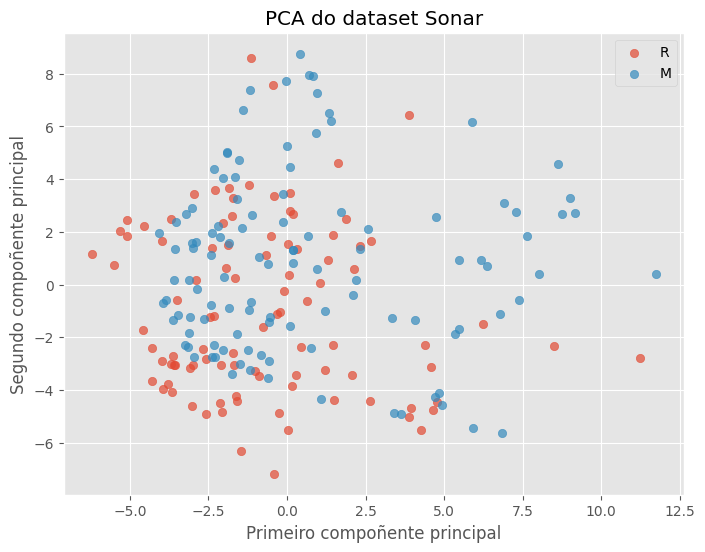

In [27]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Separar X (características) e y (clases)
X = sonarDataset.iloc[:, :-1]
y = sonarDataset.iloc[:, -1]

# Estandarizar (aínda que os datos estean en 0-1, non está de máis)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Aplicar PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plot
plt.figure(figsize=(8,6))
for clase in y.unique():
    plt.scatter(X_pca[y==clase, 0], X_pca[y==clase, 1], label=clase, alpha=0.7)
plt.xlabel('Primeiro compoñente principal')
plt.ylabel('Segundo compoñente principal')
plt.legend()
plt.title('PCA do dataset Sonar')
plt.show()

In [28]:
# TODO: aperez: Limpiar esto , no se usa
class StandardScaler:

    def __init__(self, mean=None, std=None, epsilon=1e-7):
        """Standard Scaler.
        The class can be used to normalize PyTorch Tensors using native functions. The module does not expect the
        tensors to be of any specific shape; as long as the features are the last dimension in the tensor, the module
        will work fine.
        :param mean: The mean of the features. The property will be set after a call to fit.
        :param std: The standard deviation of the features. The property will be set after a call to fit.
        :param epsilon: Used to avoid a Division-By-Zero exception.
        """
        self.mean = mean
        self.std = std
        self.epsilon = epsilon
    def fit(self, values):
        dims = list(range(values.dim() - 1))
        self.mean = torch.mean(values, dim=dims)
        self.std = torch.std(values, dim=dims)
    def transform(self, values):
        return (values - self.mean) / (self.std + self.epsilon)

    def fit_transform(self, values):
        self.fit(values)
        return self.transform(values)

    def __repr__(self):
        return f"mean: {self.mean}, std:{self.std}, epsilon:{self.epsilon}"

### Dataset en PyTorch

In [29]:
class SonarDataset(Dataset):
  def __init__(self, src_file, root_dir=None, transform=None):
    sonarDataset = pd.read_csv(src_file, header=None)
    X = sonarDataset.iloc[:, :-1].values.astype('float32')
    Y = sonarDataset.iloc[:, -1].values

    # Codificación binaria: 0 para rocha, 1 para mina
    y_bin = np.array([1 if label == 'M' else 0 for label in Y], dtype=np.int64)

    # Convertir a tensores
    x_tensor = torch.tensor(X, dtype=torch.float32)
    y_tensor = torch.as_tensor(y_bin, dtype=torch.long)
    
    # Engadimos unha dimensión para poder concatenar horizontalmente
    y_tensor = y_tensor.unsqueeze(1) 

    self.data = torch.cat((x_tensor,y_tensor),dim=1)
    self.root_dir = root_dir
    self.transform = transform
    

  def __len__(self):
    return len(self.data)

  def __getitem__(self, idx):
    if torch.is_tensor(idx):
      idx = idx.tolist()
    preds = self.data[idx, :60] # 60 primeiras columnas: características
    spcs = self.data[idx, 60].long()   # columna 60: etiqueta (0 ou 1)
    sample = (preds, spcs)
    if self.transform:
      sample = self.transform(sample)
    return sample

In [30]:
dataset = SonarDataset("../data/sonar.all-data")
display(dataset[0])
print(dataset.data.shape)

(tensor([0.0200, 0.0371, 0.0428, 0.0207, 0.0954, 0.0986, 0.1539, 0.1601, 0.3109,
         0.2111, 0.1609, 0.1582, 0.2238, 0.0645, 0.0660, 0.2273, 0.3100, 0.2999,
         0.5078, 0.4797, 0.5783, 0.5071, 0.4328, 0.5550, 0.6711, 0.6415, 0.7104,
         0.8080, 0.6791, 0.3857, 0.1307, 0.2604, 0.5121, 0.7547, 0.8537, 0.8507,
         0.6692, 0.6097, 0.4943, 0.2744, 0.0510, 0.2834, 0.2825, 0.4256, 0.2641,
         0.1386, 0.1051, 0.1343, 0.0383, 0.0324, 0.0232, 0.0027, 0.0065, 0.0159,
         0.0072, 0.0167, 0.0180, 0.0084, 0.0090, 0.0032]),
 tensor(0))

torch.Size([208, 61])


## División en Train y Test

In [31]:
longitudDataset = len(dataset)
tamTrain = int(longitudDataset*0.8)  # 166
tamVal = longitudDataset - tamTrain  # 42

train_set, val_set = random_split(dataset, [tamTrain, tamVal])

print(f"Tam dataset: {longitudDataset} train: {tamTrain} tamVal: {tamVal}")
train_ldr = torch.utils.data.DataLoader(train_set, batch_size=2,
    shuffle=True, drop_last=False)

# validation_loader =torch.utils.data.DataLoader(val_set, batch_size=4, shuffle=False, num_workers=2) # En Linux/macOS
validation_loader =torch.utils.data.DataLoader(val_set, batch_size=4, shuffle=False, num_workers=0)   


Tam dataset: 208 train: 166 tamVal: 42


In [32]:
_, dest = next(iter(train_ldr))
print(dest.dtype)  

torch.int64


## Modelo RNA (RNN)

### Craer Modelo

In [33]:
class Model(nn.Module):
    def __init__(self, input_dim):
        super(Model, self).__init__()
        self.layer1 = nn.Linear(input_dim, 50)
        self.layer2 = nn.Linear(50, 50)
        self.layer3 = nn.Linear(in_features=50, out_features=2) # En Sonar es : M, R -> 2 neuronas ( una por cada clase)
        
    def forward(self, x):
        x = F.relu(self.layer1(x))
        x = F.relu(self.layer2(x))
        x = F.softmax(self.layer3(x), dim=1)
        return x

### Instanciar Modelo
- Optimizador Adam: Ajusta los pesos de forma inteligente
- Learning rate (lr): Tamaño do paso
    - Con lr pequeña, necesitas más épocas para alcanzar un buen resultado
    - Con lr más grande, puedes necesitar menos épocas, pero hay que vigilar que no diverja

Con este dataset sonar, subí la época y lr más pequeño

In [34]:
model = Model(60) # TODO: aperez: Confirmar si tiene los mismos features del dataset - target
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005) # TODO: aperez: Cambié a lr=0.01, antes estaba con 0.001 y entrenaba mal
loss_fn   = nn.CrossEntropyLoss()
display(model)

Model(
  (layer1): Linear(in_features=60, out_features=50, bias=True)
  (layer2): Linear(in_features=50, out_features=50, bias=True)
  (layer3): Linear(in_features=50, out_features=2, bias=True)
)

### Prueba modelo

In [35]:
entradaProba, dest = next(iter(train_ldr))
print("Forma de dest:", dest.shape)
print("Tipo de dest:", dest.dtype)
print("Valores únicos en dest:", dest.unique())
saida = model(entradaProba)
print("Forma de saida:", saida.shape)
print("Tipo de saida:", saida.dtype)

Forma de dest: torch.Size([2])
Tipo de dest: torch.int64
Valores únicos en dest: tensor([0])
Forma de saida: torch.Size([2, 2])
Tipo de saida: torch.float32


In [36]:
entradaProba, dest = next(iter(train_ldr))
print("Entrada:")
display(entradaProba)
print("Desexada:")
display(dest)
saida = model(entradaProba) # esta é a proba de verdade
print("Saída:")
display(saida)
loss =loss_fn(saida, dest.long())
print("Perda:", loss.item())

Entrada:


tensor([[0.0707, 0.1252, 0.1447, 0.1644, 0.1693, 0.0844, 0.0715, 0.0947, 0.1583,
         0.1247, 0.2340, 0.1764, 0.2284, 0.3115, 0.4725, 0.5543, 0.5386, 0.3746,
         0.4583, 0.5961, 0.7464, 0.7644, 0.5711, 0.6257, 0.6695, 0.7131, 0.7567,
         0.8077, 0.8477, 0.9289, 0.9513, 0.7995, 0.4362, 0.4048, 0.4952, 0.1712,
         0.3652, 0.3763, 0.2841, 0.0427, 0.5331, 0.6952, 0.4288, 0.3063, 0.5835,
         0.5692, 0.2630, 0.1196, 0.0983, 0.0374, 0.0291, 0.0156, 0.0197, 0.0135,
         0.0127, 0.0138, 0.0133, 0.0131, 0.0154, 0.0218],
        [0.0197, 0.0394, 0.0384, 0.0076, 0.0251, 0.0629, 0.0747, 0.0578, 0.1357,
         0.1695, 0.1734, 0.2470, 0.3141, 0.3297, 0.2759, 0.2056, 0.1162, 0.1884,
         0.3390, 0.3926, 0.4282, 0.5418, 0.6448, 0.7223, 0.7853, 0.7984, 0.8847,
         0.9582, 0.8990, 0.6831, 0.6108, 0.5480, 0.5058, 0.4476, 0.2401, 0.1405,
         0.1772, 0.1742, 0.3326, 0.4021, 0.3009, 0.2075, 0.1206, 0.0255, 0.0298,
         0.0691, 0.0781, 0.0777, 0.0369, 0.0057, 0.

Desexada:


tensor([1, 1])

Saída:


tensor([[0.5208, 0.4792],
        [0.5129, 0.4871]], grad_fn=<SoftmaxBackward0>)

Perda: 0.7101370692253113


## Entrenamiento

In [37]:
def train_one_epoch(epoch_index, tb_writer):
    running_loss = 0.
    last_loss = 0.
    # usamos enumerate para saber en que batch imos
    for i, data in enumerate(train_ldr):
        # Every data instance is an input + label pair
        inputs, labels = data
        # Zero your gradients for every batch!
        optimizer.zero_grad()
        # Make predictions for this batch
        outputs = model(inputs)
        # Compute the loss and its gradients
        loss = loss_fn(outputs, labels)
        loss.backward()
        # Adjust learning weights
        optimizer.step()
        # Gather data and report
        running_loss += loss.item()
        if i % 10 == 9:
            last_loss = running_loss / 10 # loss per batch
            print('  batch {} loss: {}'.format(i + 1, last_loss))
            running_loss = 0.
    return last_loss

**Épocas(EPOCHS)**: Número de veces que el modelo ve todos los datos
- Si la curva aun sube, se puede aumentar
- Si está plana ya vale

Se ve en *validation accuract* (gráfica paso siguiente)

En este dataset subí a 200 épocas

In [38]:
from torch.utils.tensorboard import SummaryWriter

# 1. ARREGLO DE RUTA: Subimos un nivel (../) para que se guarde en la raíz del proyecto
writer = SummaryWriter('../runs/experimento_sonar_pro') 

# 2. DIBUJAR LA RED (GRAPH): Cogemos un dato de prueba y pintamos el esquema
dummy_inputs, _ = next(iter(validation_loader))
writer.add_graph(model, dummy_inputs)

EPOCHS = 200
loss_list     = torch.zeros((EPOCHS,))
accuracy_list = torch.zeros((EPOCHS,))

for epoch in range(EPOCHS):
    print('EPOCH {}:'.format(epoch + 1))

    # --- ENTRENAMIENTO ---
    model.train(True)
    avg_loss = train_one_epoch(epoch, writer)
    loss_list[epoch] = avg_loss
    
    # --- VALIDACIÓN ---
    model.train(False)
    running_vloss = 0.0
    correct_total = 0
    total_samples = 0
    
    for i, vdata in enumerate(validation_loader):
        vinputs, vlabels = vdata
        voutputs = model(vinputs)
        vloss = loss_fn(voutputs, vlabels)
        running_vloss += vloss.item()

        pred = torch.argmax(voutputs, dim=1)
        correct_total += (pred == vlabels).sum().item()
        total_samples += vlabels.size(0)
    
    # Cálculos finales
    avg_vloss = running_vloss / (i + 1)
    accuracy = 100.0 * correct_total / total_samples
    accuracy_list[epoch] = accuracy
    
    print('EPOCH {}: LOSS train {:.4f} valid {:.4f} | Acc: {:.2f}%'.format(
        epoch + 1, avg_loss, avg_vloss, accuracy
    ))

    # ==========================================
    # 📊 PANEL DE CONTROL TENSORBOARD PRO 📊
    # ==========================================
    
    # A. Gráfica combinada: Entrenamiento vs Validación en el mismo cuadro
    writer.add_scalars('Rendimiento/Loss_Combinado', {
        'Entrenamiento': avg_loss,
        'Validacion': avg_vloss
    }, epoch)
    
    # B. Métrica suelta: Porcentaje de acierto
    writer.add_scalar('Rendimiento/Accuracy', accuracy, epoch)
    
    # C. Histogramas: Ver si los "pesos" del cerebro de la red están cambiando
    for name, param in model.named_parameters():
        writer.add_histogram(f'Pesos_Internos/{name}', param.clone().cpu().data.numpy(), epoch)
    
    # ==========================================

writer.flush()
writer.close()

EPOCH 1:
  batch 10 loss: 0.6945562601089478
  batch 20 loss: 0.6925882577896119
  batch 30 loss: 0.6924494862556457
  batch 40 loss: 0.6870312392711639
  batch 50 loss: 0.6900975227355957
  batch 60 loss: 0.6866971671581268
  batch 70 loss: 0.672038322687149
  batch 80 loss: 0.6853908061981201
EPOCH 1: LOSS train 0.6854 valid 0.6965 | Acc: 45.24%
EPOCH 2:
  batch 10 loss: 0.6900555729866028
  batch 20 loss: 0.6804445266723633
  batch 30 loss: 0.6718626081943512
  batch 40 loss: 0.6846904039382935
  batch 50 loss: 0.674475759267807
  batch 60 loss: 0.6848913371562958
  batch 70 loss: 0.6946844577789306
  batch 80 loss: 0.66293705701828
EPOCH 2: LOSS train 0.6629 valid 0.6893 | Acc: 45.24%
EPOCH 3:
  batch 10 loss: 0.6801239609718323
  batch 20 loss: 0.6845789909362793
  batch 30 loss: 0.6905800998210907
  batch 40 loss: 0.6600989758968353
  batch 50 loss: 0.6627104103565216
  batch 60 loss: 0.6888703823089599
  batch 70 loss: 0.6208867073059082
  batch 80 loss: 0.6320382118225097
EPOCH

## Mostrar gráfica

Text(0.5, 0, 'epochs')

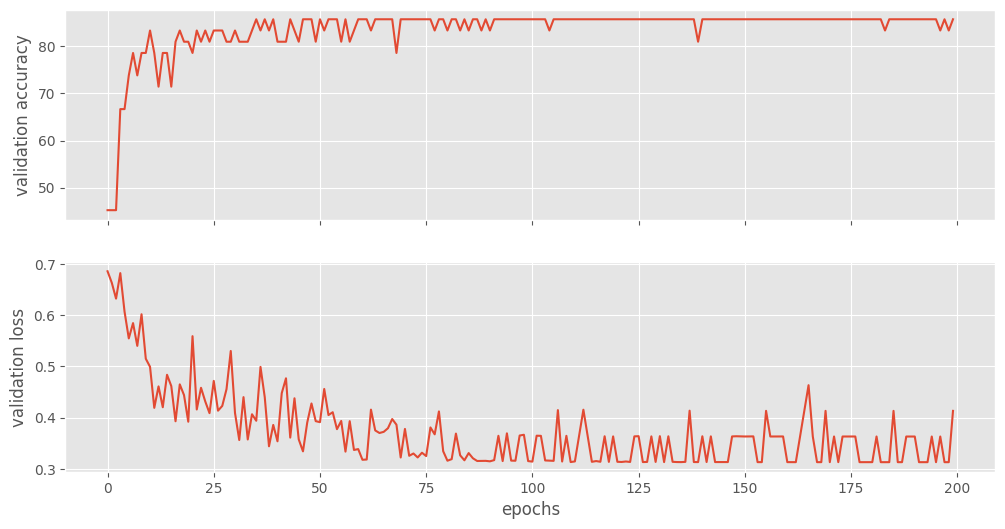

In [39]:
plt.style.use('ggplot')
fig, (ax1, ax2) = plt.subplots(2, figsize=(12, 6), sharex=True)

ax1.plot(accuracy_list)
ax1.set_ylabel("validation accuracy")
ax2.plot(loss_list)
ax2.set_ylabel("validation loss")
ax2.set_xlabel("epochs")

## Persistencia del Modelo (Exportación del state_dict)

In [40]:
# Definimos el nombre de la carpeta y creamos la ruta completa
carpeta_modelos = 'modelos'
ruta_archivo = os.path.join(carpeta_modelos, 'modelo_sonar_entrenado.pth')

os.makedirs(carpeta_modelos, exist_ok=True)

# Guardamos el "cerebro" de la red en esa nueva ruta
torch.save(model.state_dict(), ruta_archivo)

print(f"¡Modelo guardado exitosamente en la ruta: {ruta_archivo}!")

¡Modelo guardado exitosamente en la ruta: modelos\modelo_sonar_entrenado.pth!


## Predicción del modelo

In [41]:
state_dict = torch.load('modelos/modelo_sonar_entrenado.pth')
model.load_state_dict(state_dict)

model.eval()

# Recojo una muestra de que es Roca (sonar.all-data : linea 10)
nova_mostra = [0.0164,0.0173,0.0347,0.0070,0.0187,0.0671,0.1056,0.0697,0.0962,0.0251,0.0801,0.1056,0.1266,0.0890,0.0198,0.1133,0.2826,0.3234,0.3238,0.4333,0.6068,0.7652,0.9203,0.9719,0.9207,0.7545,0.8289,0.8907,0.7309,0.6896,0.5829,0.4935,0.3101,0.0306,0.0244,0.1108,0.1594,0.1371,0.0696,0.0452,0.0620,0.1421,0.1597,0.1384,0.0372,0.0688,0.0867,0.0513,0.0092,0.0198,0.0118,0.0090,0.0223,0.0179,0.0084,0.0068,0.0032,0.0035,0.0056,0.0040]  # 60 números

# Converter a tensor e engadir dimensión batch
input_tensor = torch.tensor(nova_mostra, dtype=torch.float32).unsqueeze(0)  # forma (1, 60)

In [42]:
with torch.no_grad():
    saida = model(input_tensor)
    clase = torch.argmax(saida, dim=1).item()
    prob = torch.softmax(saida, dim=1)[0, 1].item()

# Resultado
clase_nome = "Mina" if clase == 1 else "Roca"
print(f"Clase predicha: {clase_nome} (probabilidad de ser mina: {prob:.3f})")

Clase predicha: Roca (probabilidad de ser mina: 0.269)
